# 🧠 ZuCo EEG Dataset — Exploratory Data Analysis

This notebook provides a comprehensive EDA of the ZuCo EEG-Text dataset used in the **Gated-GLIM** project.  
It covers both the **raw/intermediate** data (`zuco_eeg_128ch_1280len.df`) and the **final preprocessed** data (`zuco_eeg_label_8variants.df`).

### Pipeline Overview
```
Raw .mat files (500Hz, 105ch) 
  → STEP3: Downsample to 128Hz, pad to 1280×128
  → zuco_eeg_128ch_1280len.df  (22,335 samples)
  → STEP4: Match labels, text variants, train/val/test split
  → zuco_eeg_label_8variants.df (22,335 samples, 22 columns)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')
palette = sns.color_palette('Set2')

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 1. Load Data

In [2]:
# ---------- Intermediate (before label matching & splitting) ----------
raw_path = './data/tmp/zuco_eeg_128ch_1280len.df'
try:
    df_raw = pd.read_pickle(raw_path)
    print(f'✅ Loaded intermediate data: {raw_path}')
    print(f'   Shape: {df_raw.shape}')
    print(f'   Columns: {list(df_raw.columns)}')
    HAS_RAW = True
except FileNotFoundError:
    print(f'⚠️ Intermediate file not found: {raw_path} — skipping raw analysis')
    HAS_RAW = False

print()

# ---------- Final preprocessed data ----------
proc_path = './data/tmp/zuco_eeg_label_8variants.df'
df = pd.read_pickle(proc_path)
print(f'✅ Loaded final preprocessed data: {proc_path}')
print(f'   Shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')

✅ Loaded intermediate data: ./data/tmp/zuco_eeg_128ch_1280len.df
   Shape: (22335, 6)
   Columns: ['eeg', 'mask', 'text', 'dataset', 'task', 'subject']

✅ Loaded final preprocessed data: ./data/tmp/zuco_eeg_label_8variants.df
   Shape: (22335, 22)
   Columns: ['eeg', 'mask', 'subject', 'label id', 'raw text', 'dataset', 'task', 'control', 'raw label', 'input text', 'text uid', 'sentiment label', 'relation label', 'lexical simplification (v0)', 'lexical simplification (v1)', 'semantic clarity (v0)', 'semantic clarity (v1)', 'syntax simplification (v0)', 'syntax simplification (v1)', 'naive rewritten', 'naive simplified', 'phase']


---
## 2. Dataset Overview & Schema

In [3]:
print('='*70)
print('FINAL PREPROCESSED DATASET SCHEMA')
print('='*70)
for col in df.columns:
    val = df[col].iloc[0]
    if isinstance(val, np.ndarray):
        desc = f'numpy array, shape={val.shape}, dtype={val.dtype}'
    elif isinstance(val, str):
        desc = f'string, example="{val[:60]}..."' if len(val) > 60 else f'string, example="{val}"'
    else:
        desc = f'{type(val).__name__}, example={val}'
    print(f'  {col:40s} → {desc}')

print(f'\nTotal samples: {len(df):,}')
print(f'Unique texts:  {df["text uid"].nunique()}')
print(f'Unique subjects: {df["subject"].nunique()}')

FINAL PREPROCESSED DATASET SCHEMA
  eeg                                      → numpy array, shape=(1280, 128), dtype=float32
  mask                                     → numpy array, shape=(1280,), dtype=int8
  subject                                  → string, example="ZAB"
  label id                                 → int64, example=0
  raw text                                 → string, example="Presents a good case while failing to provide a reason for u..."
  dataset                                  → string, example="ZuCo1"
  task                                     → string, example="task1"
  control                                  → bool_, example=False
  raw label                                → string, example="0"
  input text                               → string, example="Presents a good case while failing to provide a reason for u..."
  text uid                                 → int64, example=0
  sentiment label                          → string, example="neutral"
  rela

---
## 3. Dataset & Task Distribution

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\01_dataset_task_distribution.png'

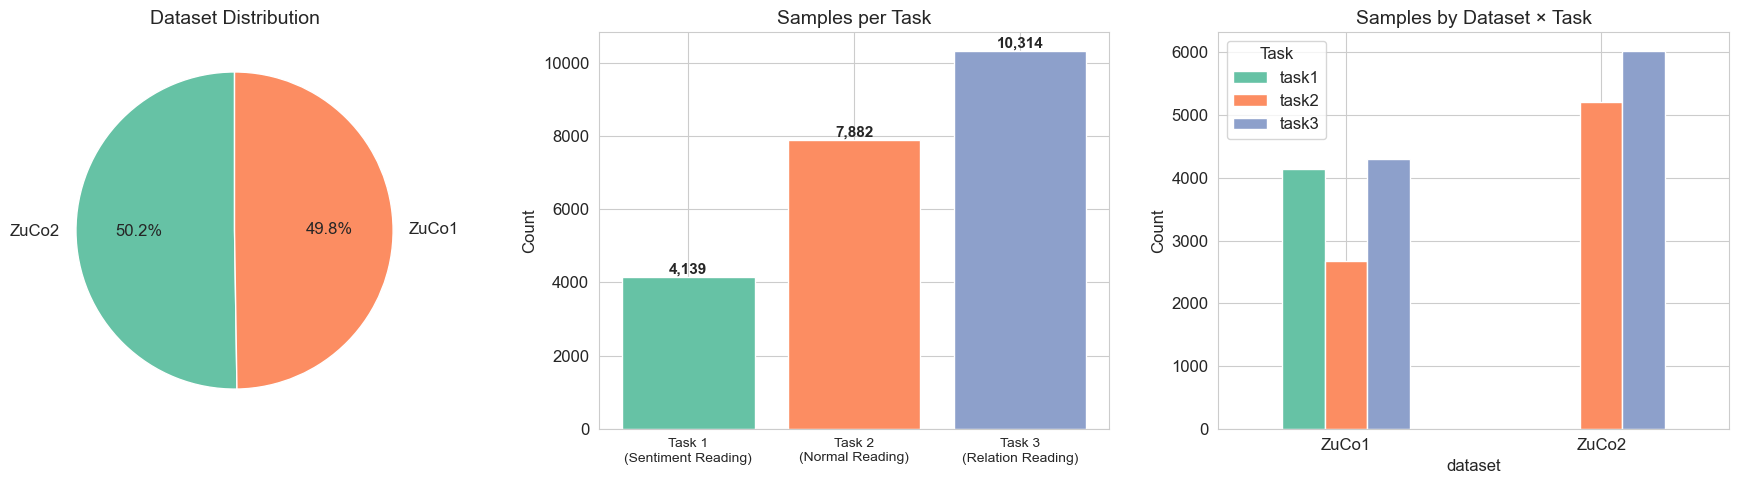

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Dataset distribution
df['dataset'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', 
                                      colors=palette[:2], startangle=90)
axes[0].set_title('Dataset Distribution')
axes[0].set_ylabel('')

# (b) Task distribution
task_counts = df['task'].value_counts().sort_index()
task_labels = {'task1': 'Task 1\n(Sentiment Reading)', 
               'task2': 'Task 2\n(Normal Reading)', 
               'task3': 'Task 3\n(Relation Reading)'}
bars = axes[1].bar(range(len(task_counts)), task_counts.values, color=palette[:3])
axes[1].set_xticks(range(len(task_counts)))
axes[1].set_xticklabels([task_labels.get(t, t) for t in task_counts.index], fontsize=10)
axes[1].set_title('Samples per Task')
axes[1].set_ylabel('Count')
for bar, val in zip(bars, task_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# (c) Dataset × Task
ct = pd.crosstab(df['dataset'], df['task'])
ct.plot.bar(ax=axes[2], color=palette[:3], rot=0)
axes[2].set_title('Samples by Dataset × Task')
axes[2].set_ylabel('Count')
axes[2].legend(title='Task')

plt.tight_layout()
plt.savefig('./eda_figures/01_dataset_task_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Train / Validation / Test Split

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\02_train_val_test_split.png'

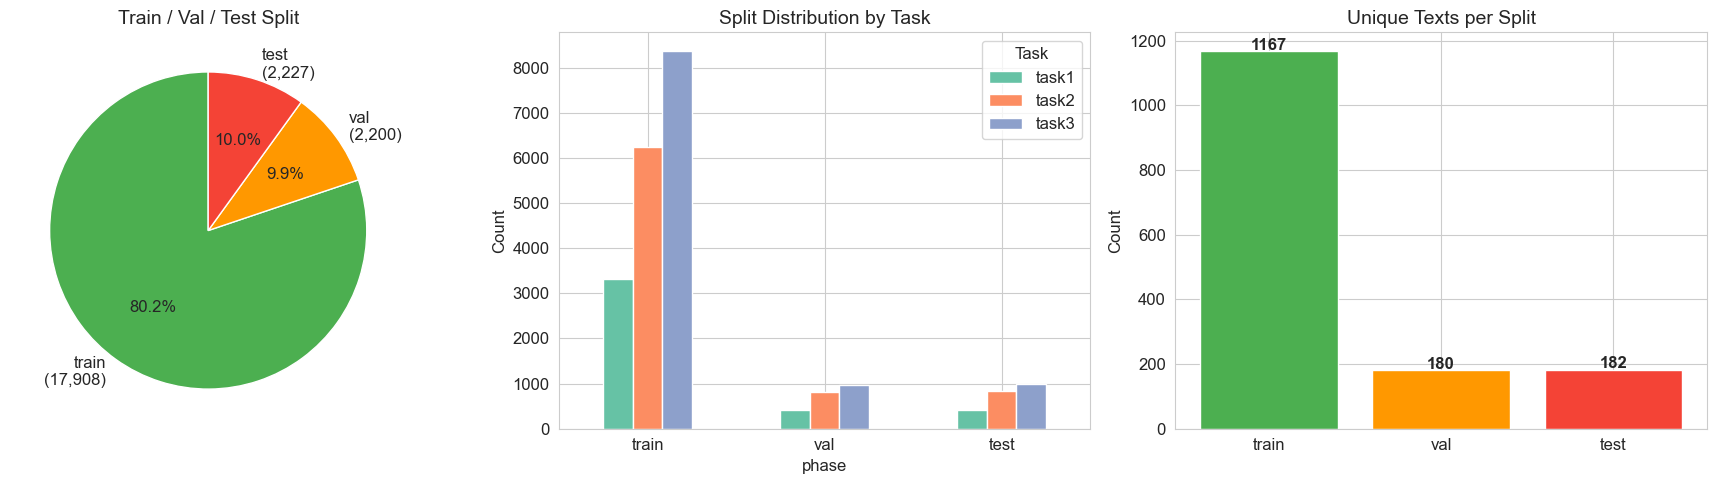

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Overall split
split_counts = df['phase'].value_counts().reindex(['train', 'val', 'test'])
colors_split = ['#4CAF50', '#FF9800', '#F44336']
axes[0].pie(split_counts, labels=[f'{p}\n({c:,})' for p, c in split_counts.items()],
            autopct='%1.1f%%', colors=colors_split, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Train / Val / Test Split')

# (b) Split by task
phase_task = df.groupby(['phase', 'task']).size().unstack(fill_value=0)
phase_task = phase_task.reindex(['train', 'val', 'test'])
phase_task.plot.bar(ax=axes[1], color=palette[:3], rot=0)
axes[1].set_title('Split Distribution by Task')
axes[1].set_ylabel('Count')
axes[1].legend(title='Task')

# (c) Unique texts per split
unique_texts = df.groupby('phase')['text uid'].nunique().reindex(['train', 'val', 'test'])
bars = axes[2].bar(unique_texts.index, unique_texts.values, color=colors_split)
for bar, val in zip(bars, unique_texts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Unique Texts per Split')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('./eda_figures/02_train_val_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDetailed split breakdown:')
print(phase_task.to_string())

---
## 5. Subject-Level Analysis

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\03_subject_distribution.png'

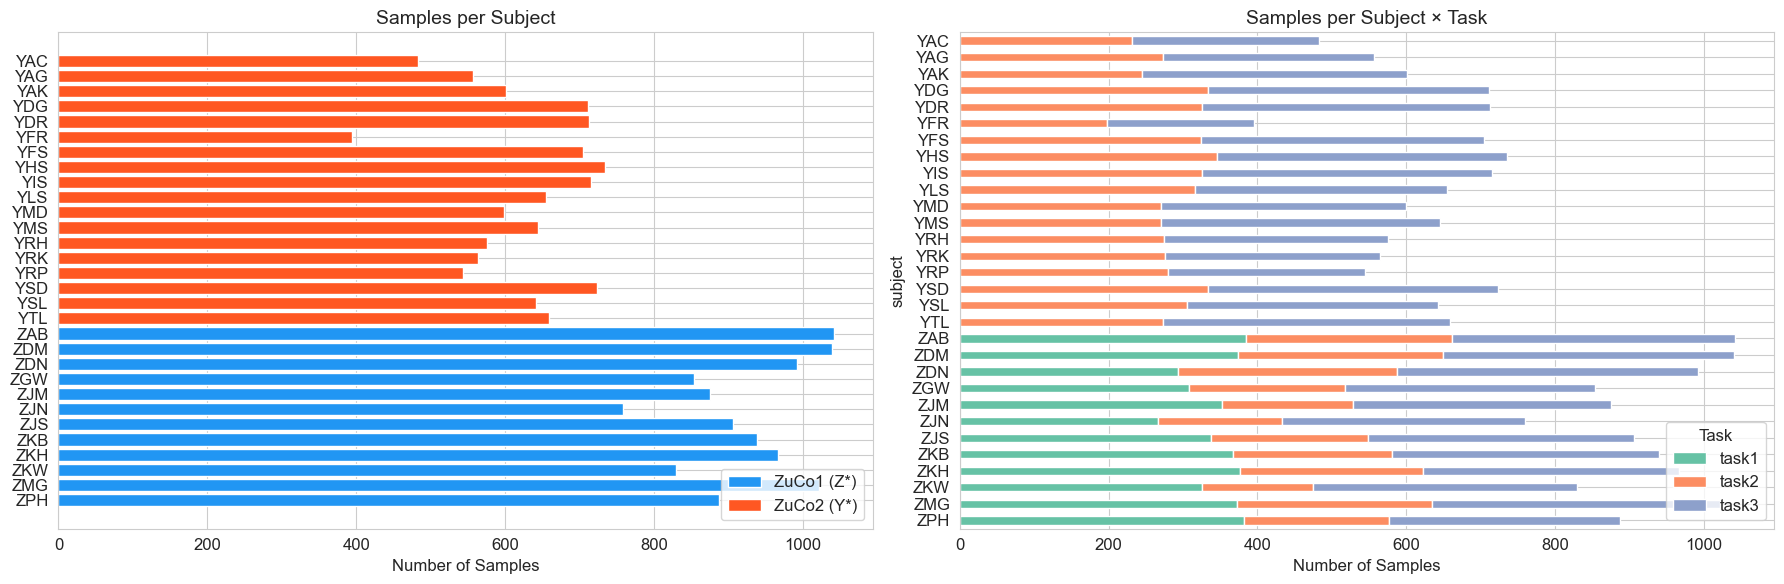

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (a) Samples per subject
subject_counts = df['subject'].value_counts().sort_index()
colors_subj = ['#2196F3' if s.startswith('Z') else '#FF5722' for s in subject_counts.index]
axes[0].barh(subject_counts.index, subject_counts.values, color=colors_subj)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Samples per Subject')
axes[0].invert_yaxis()
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='ZuCo1 (Z*)'),
                   Patch(facecolor='#FF5722', label='ZuCo2 (Y*)')]
axes[0].legend(handles=legend_elements, loc='lower right')

# (b) Samples per subject per task (stacked)
subj_task = df.groupby(['subject', 'task']).size().unstack(fill_value=0)
subj_task = subj_task.sort_index()
subj_task.plot.barh(ax=axes[1], stacked=True, color=palette[:3])
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('Samples per Subject × Task')
axes[1].invert_yaxis()
axes[1].legend(title='Task', loc='lower right')

plt.tight_layout()
plt.savefig('./eda_figures/03_subject_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nZuCo1 subjects (Z*): {sorted([s for s in df["subject"].unique() if s.startswith("Z")])}')
print(f'ZuCo2 subjects (Y*): {sorted([s for s in df["subject"].unique() if s.startswith("Y")])}')

---
## 6. EEG Signal Analysis (Before vs After Preprocessing)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\04_eeg_signal_examples.png'

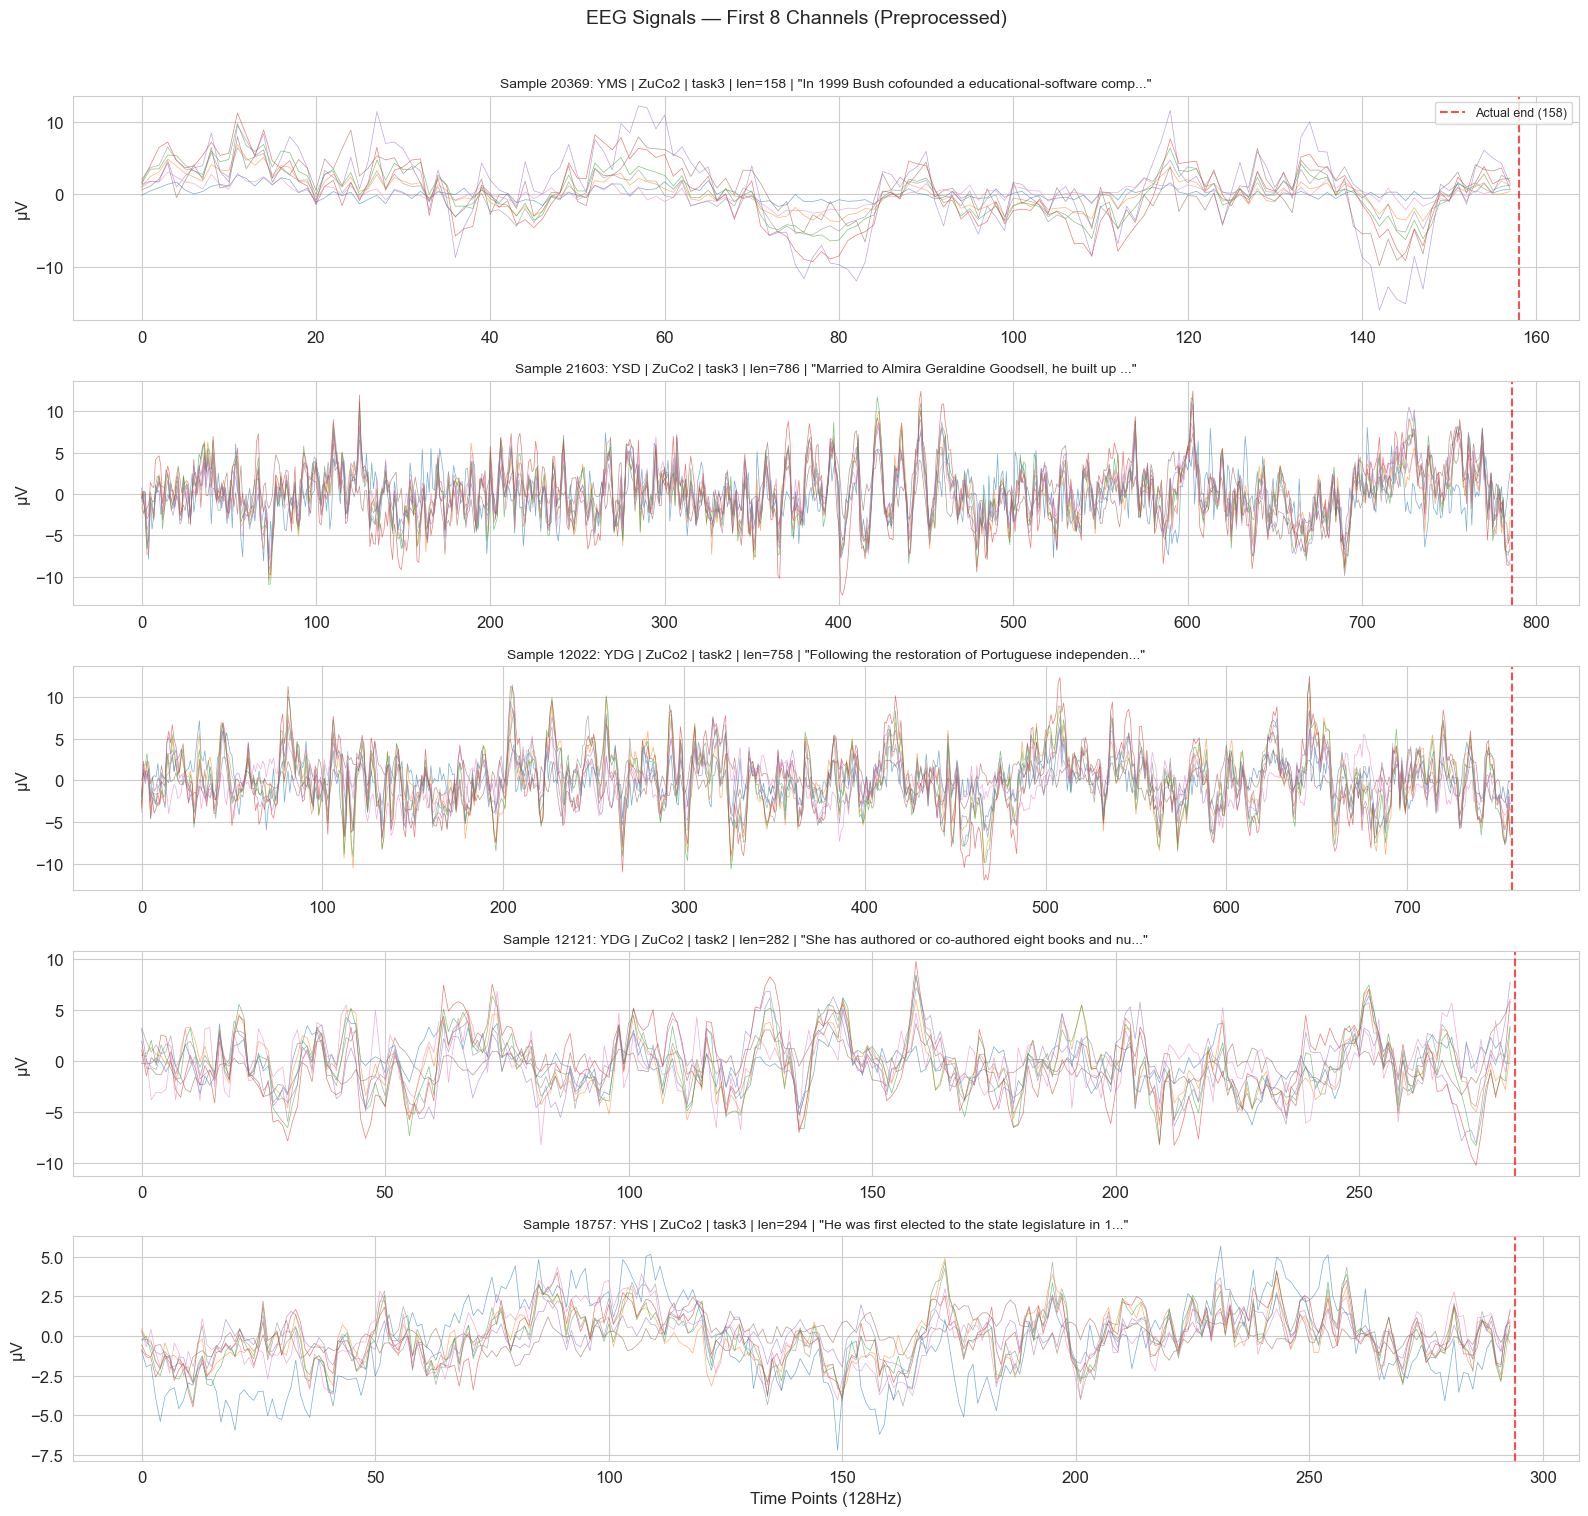

In [7]:
# Sample a few EEG signals for visualization
np.random.seed(42)
sample_indices = np.random.choice(len(df), size=5, replace=False)

fig, axes = plt.subplots(5, 1, figsize=(16, 15))

for i, idx in enumerate(sample_indices):
    row = df.iloc[idx]
    eeg = row['eeg']  # (1280, 128)
    mask = row['mask']  # (1280,)
    actual_len = mask.sum()
    
    # Plot first 8 channels
    for ch in range(8):
        axes[i].plot(eeg[:actual_len, ch], alpha=0.6, linewidth=0.5)
    
    axes[i].axvline(x=actual_len, color='red', linestyle='--', alpha=0.7, label=f'Actual end ({actual_len})')
    axes[i].set_title(f'Sample {idx}: {row["subject"]} | {row["dataset"]} | {row["task"]} | '
                      f'len={actual_len} | "{row["input text"][:50]}..."', fontsize=10)
    axes[i].set_ylabel('μV')
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time Points (128Hz)')
fig.suptitle('EEG Signals — First 8 Channels (Preprocessed)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('./eda_figures/04_eeg_signal_examples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. EEG Statistics & Distribution

KeyboardInterrupt: 

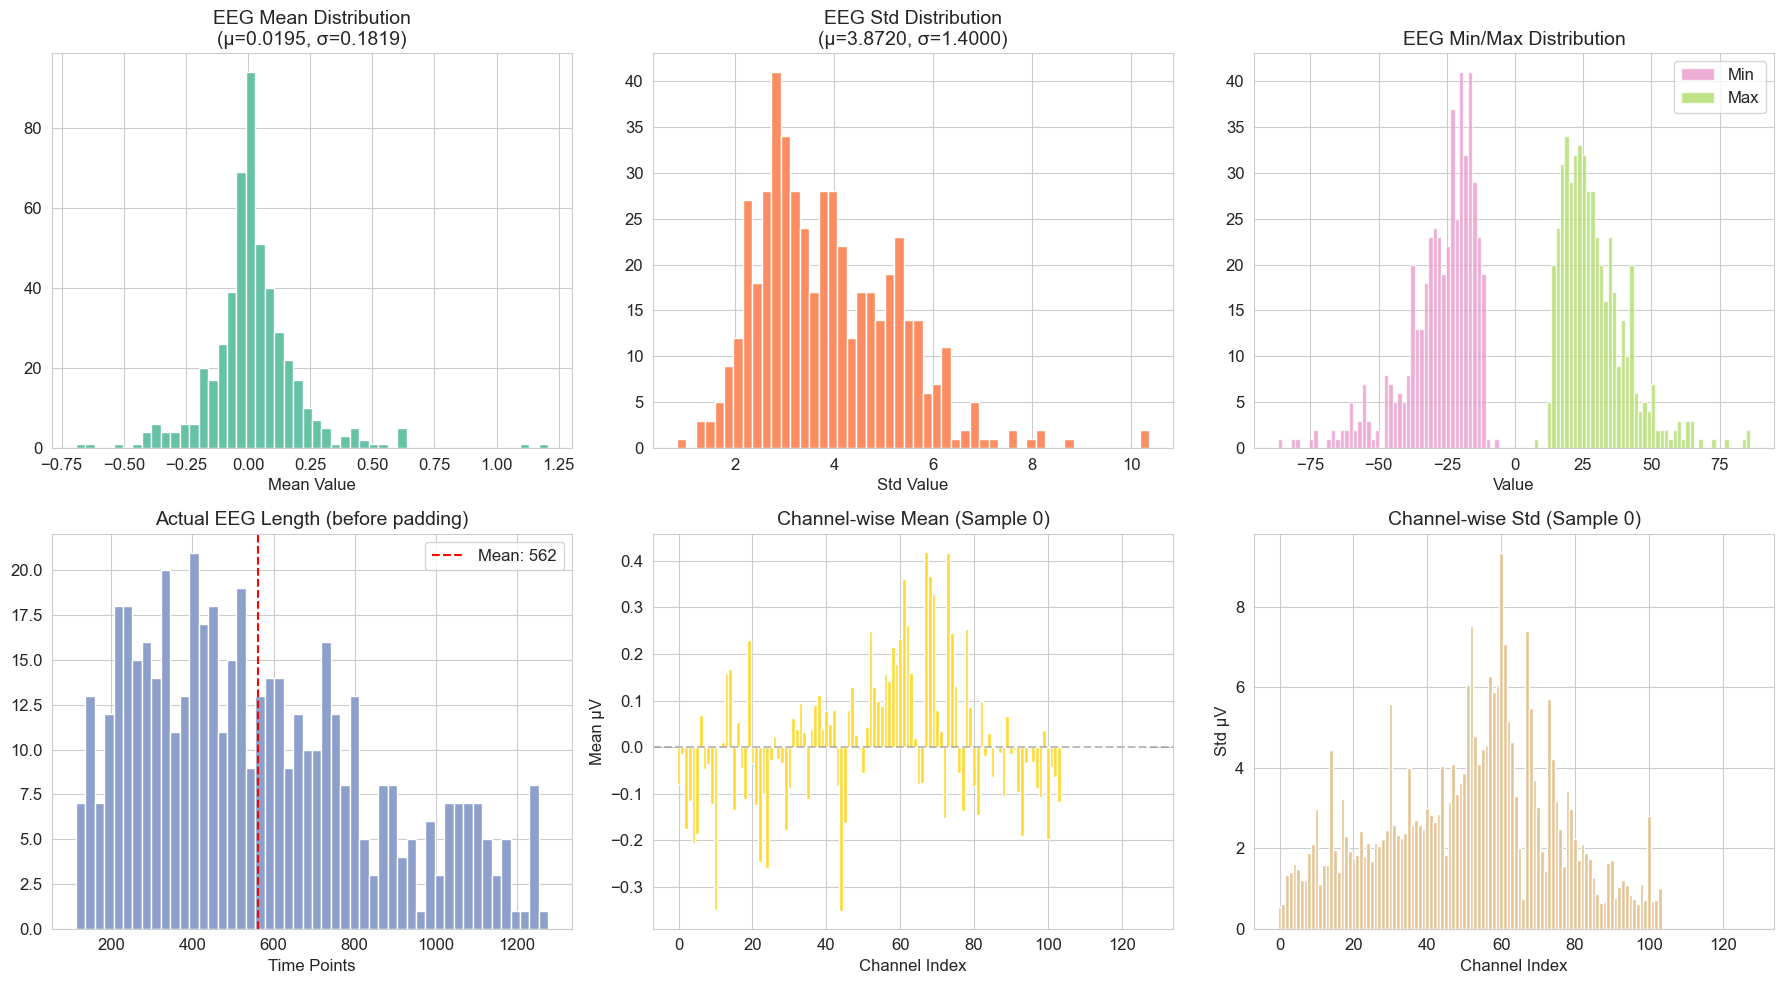

In [8]:
# Compute EEG statistics across a random subset (full dataset is too large)
np.random.seed(42)
n_stat_samples = min(500, len(df))
stat_indices = np.random.choice(len(df), size=n_stat_samples, replace=False)

eeg_means = []
eeg_stds = []
eeg_mins = []
eeg_maxs = []
actual_lengths = []

for idx in stat_indices:
    row = df.iloc[idx]
    eeg = row['eeg']
    mask = row['mask']
    actual_len = mask.sum()
    eeg_valid = eeg[:actual_len, :]
    
    eeg_means.append(eeg_valid.mean())
    eeg_stds.append(eeg_valid.std())
    eeg_mins.append(eeg_valid.min())
    eeg_maxs.append(eeg_valid.max())
    actual_lengths.append(actual_len)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (a) Mean distribution
axes[0, 0].hist(eeg_means, bins=50, color=palette[0], edgecolor='white')
axes[0, 0].set_title(f'EEG Mean Distribution\n(μ={np.mean(eeg_means):.4f}, σ={np.std(eeg_means):.4f})')
axes[0, 0].set_xlabel('Mean Value')

# (b) Std distribution
axes[0, 1].hist(eeg_stds, bins=50, color=palette[1], edgecolor='white')
axes[0, 1].set_title(f'EEG Std Distribution\n(μ={np.mean(eeg_stds):.4f}, σ={np.std(eeg_stds):.4f})')
axes[0, 1].set_xlabel('Std Value')

# (c) Min/Max range
axes[0, 2].hist(eeg_mins, bins=50, color=palette[3], edgecolor='white', alpha=0.7, label='Min')
axes[0, 2].hist(eeg_maxs, bins=50, color=palette[4], edgecolor='white', alpha=0.7, label='Max')
axes[0, 2].set_title('EEG Min/Max Distribution')
axes[0, 2].set_xlabel('Value')
axes[0, 2].legend()

# (d) Actual signal length distribution
axes[1, 0].hist(actual_lengths, bins=50, color=palette[2], edgecolor='white')
axes[1, 0].axvline(np.mean(actual_lengths), color='red', linestyle='--', 
                    label=f'Mean: {np.mean(actual_lengths):.0f}')
axes[1, 0].set_title('Actual EEG Length (before padding)')
axes[1, 0].set_xlabel('Time Points')
axes[1, 0].legend()

# (e) Channel-wise mean (single sample)
sample_eeg = df.iloc[0]['eeg']
sample_mask = df.iloc[0]['mask']
ch_means = sample_eeg[:sample_mask.sum(), :].mean(axis=0)
axes[1, 1].bar(range(len(ch_means)), ch_means, color=palette[5], width=1.0)
axes[1, 1].set_title('Channel-wise Mean (Sample 0)')
axes[1, 1].set_xlabel('Channel Index')
axes[1, 1].set_ylabel('Mean μV')
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)

# (f) Channel-wise std (single sample)
ch_stds = sample_eeg[:sample_mask.sum(), :].std(axis=0)
axes[1, 2].bar(range(len(ch_stds)), ch_stds, color=palette[6], width=1.0)
axes[1, 2].set_title('Channel-wise Std (Sample 0)')
axes[1, 2].set_xlabel('Channel Index')
axes[1, 2].set_ylabel('Std μV')

plt.tight_layout()
plt.savefig('./eda_figures/05_eeg_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 EEG Statistics Summary (computed from {n_stat_samples} samples):')
print(f'   Mean of means:  {np.mean(eeg_means):.6f}')
print(f'   Mean of stds:   {np.mean(eeg_stds):.4f}')
print(f'   Global min:     {np.min(eeg_mins):.4f}')
print(f'   Global max:     {np.max(eeg_maxs):.4f}')
print(f'   Mean length:    {np.mean(actual_lengths):.0f} / 1280 time points')
print(f'   Min length:     {np.min(actual_lengths)}')
print(f'   Max length:     {np.max(actual_lengths)}')

---
## 8. EEG Heatmap (Time × Channel)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\06_eeg_heatmaps.png'

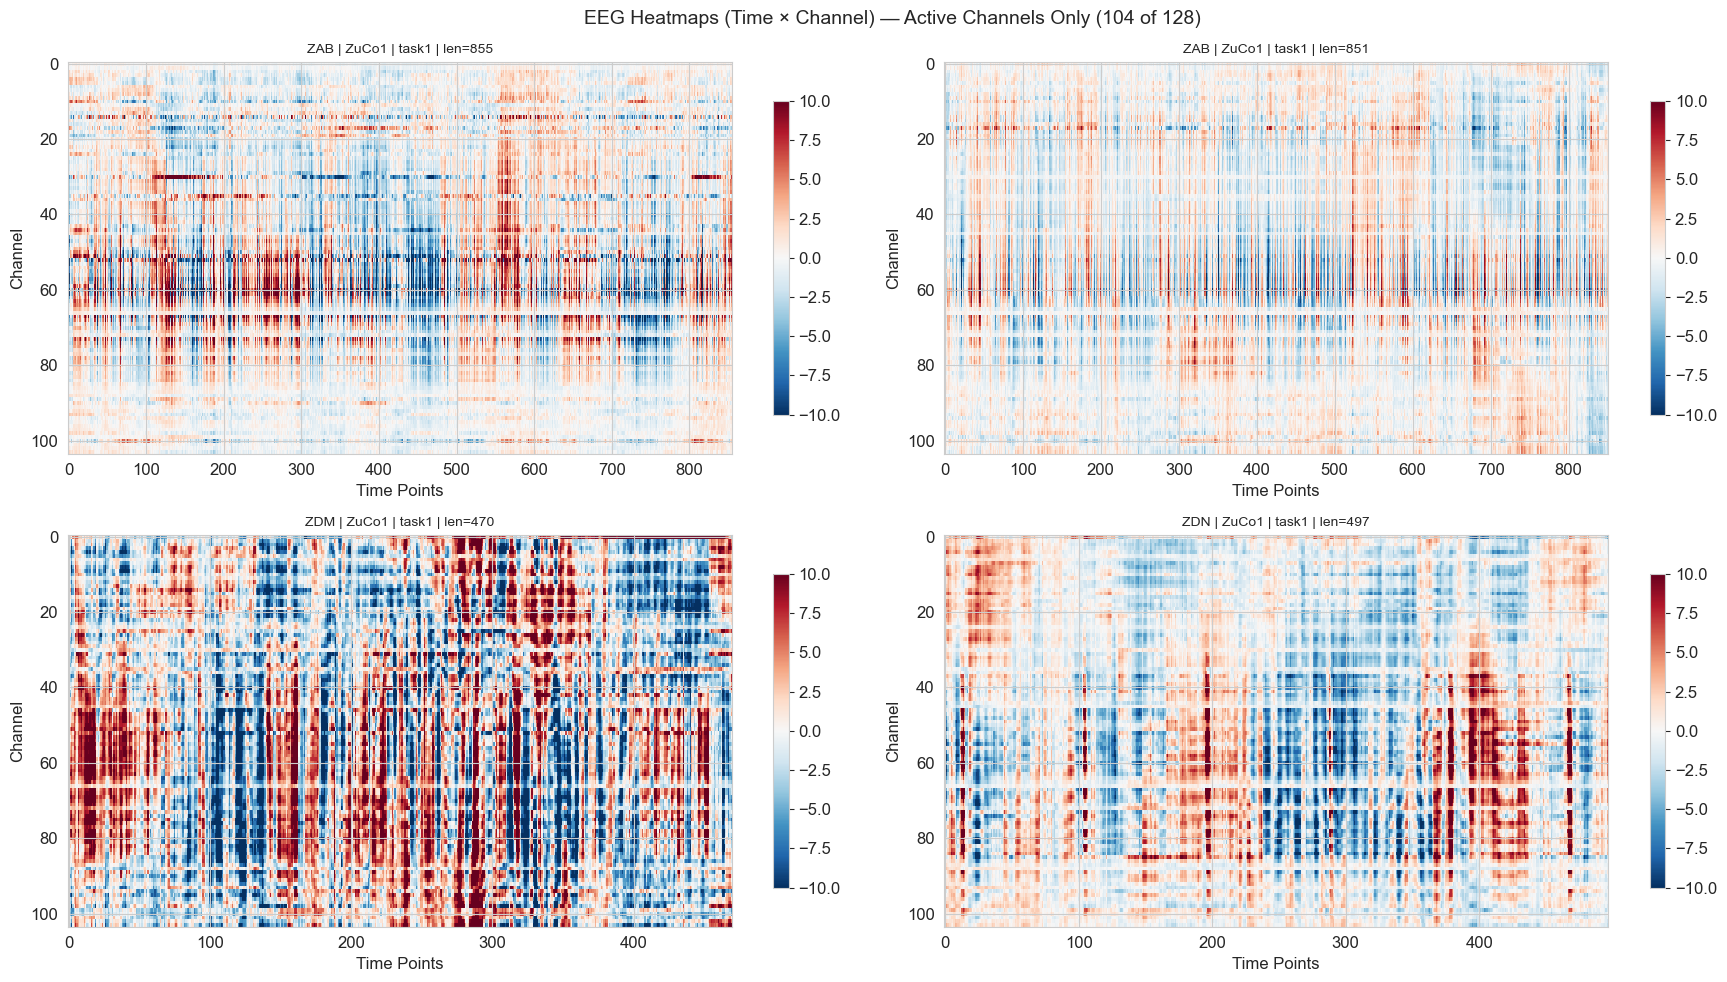

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, idx in enumerate([0, 100, 500, 1000]):
    if idx >= len(df):
        idx = i
    row = df.iloc[idx]
    eeg = row['eeg']  # (1280, 128)
    mask = row['mask']
    actual_len = mask.sum()
    
    ax = axes[i // 2, i % 2]
    im = ax.imshow(eeg[:actual_len, :104].T, aspect='auto', cmap='RdBu_r',
                   vmin=-10, vmax=10, interpolation='none')
    ax.set_title(f'{row["subject"]} | {row["dataset"]} | {row["task"]} | len={actual_len}', fontsize=10)
    ax.set_xlabel('Time Points')
    ax.set_ylabel('Channel')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('EEG Heatmaps (Time × Channel) — Active Channels Only (104 of 128)', fontsize=14)
plt.tight_layout()
plt.savefig('./eda_figures/06_eeg_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Mask Analysis (Zero-Padding)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\07_mask_padding_analysis.png'

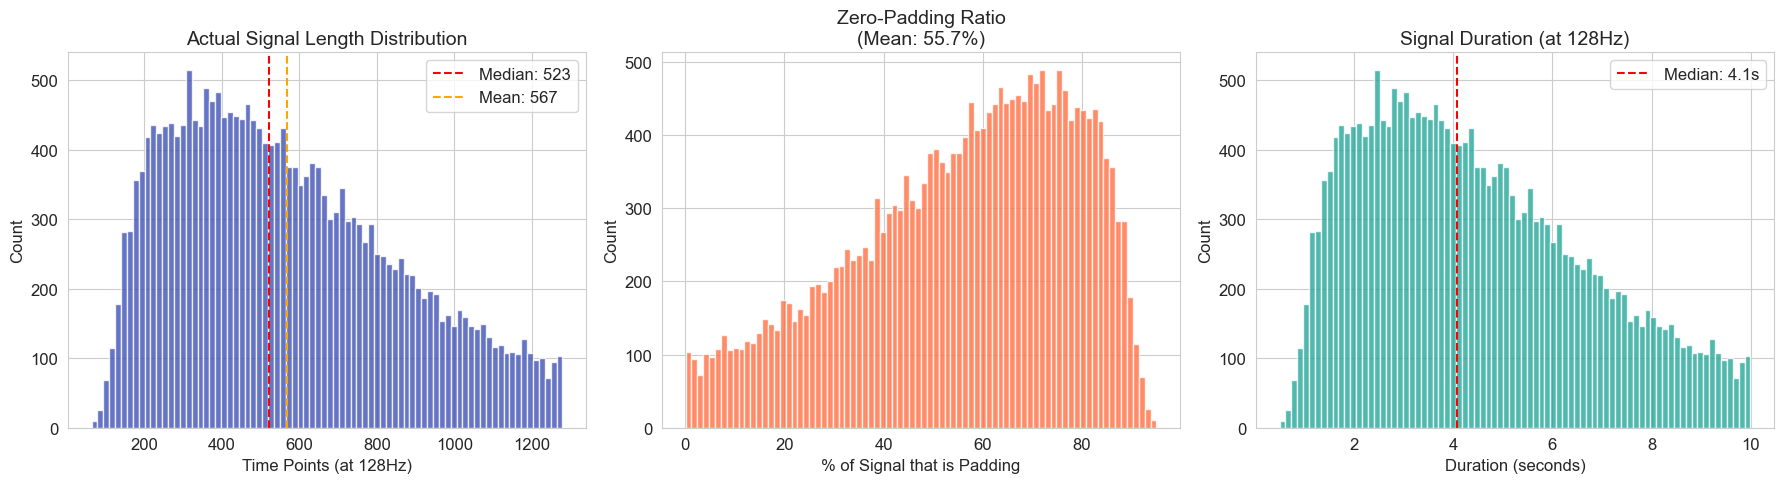

In [10]:
# Compute mask statistics for all samples
all_lengths = [row['mask'].sum() for _, row in df.iterrows()]
all_lengths = np.array(all_lengths)
padding_ratios = 1 - (all_lengths / 1280)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Signal length distribution 
axes[0].hist(all_lengths, bins=80, color='#3F51B5', edgecolor='white', alpha=0.8)
axes[0].axvline(np.median(all_lengths), color='red', linestyle='--', 
                label=f'Median: {np.median(all_lengths):.0f}')
axes[0].axvline(np.mean(all_lengths), color='orange', linestyle='--', 
                label=f'Mean: {np.mean(all_lengths):.0f}')
axes[0].set_title('Actual Signal Length Distribution')
axes[0].set_xlabel('Time Points (at 128Hz)')
axes[0].set_ylabel('Count')
axes[0].legend()

# (b) Padding ratio distribution
axes[1].hist(padding_ratios * 100, bins=80, color='#FF7043', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Zero-Padding Ratio\n(Mean: {padding_ratios.mean()*100:.1f}%)')
axes[1].set_xlabel('% of Signal that is Padding')
axes[1].set_ylabel('Count')

# (c) Duration in seconds (at 128Hz)
durations = all_lengths / 128  # seconds
axes[2].hist(durations, bins=80, color='#26A69A', edgecolor='white', alpha=0.8)
axes[2].axvline(np.median(durations), color='red', linestyle='--', 
                label=f'Median: {np.median(durations):.1f}s')
axes[2].set_title('Signal Duration (at 128Hz)')
axes[2].set_xlabel('Duration (seconds)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('./eda_figures/07_mask_padding_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Duration by task
df['actual_len'] = all_lengths
df['duration_s'] = durations

print('\nSignal duration by task (seconds):')
print(df.groupby('task')['duration_s'].describe().round(2).to_string())

---
## 10. Text Analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Text length (character count)
df['text_len_chars'] = df['input text'].str.len()
df['text_len_words'] = df['input text'].str.split().str.len()

# (a) Word count distribution
axes[0].hist(df['text_len_words'], bins=50, color='#7E57C2', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Text Length (Words)\nMean: {df["text_len_words"].mean():.1f}')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

# (b) Word count by task
for task in sorted(df['task'].unique()):
    subset = df[df['task'] == task]['text_len_words']
    axes[1].hist(subset, bins=40, alpha=0.5, label=f'{task} (μ={subset.mean():.1f})')
axes[1].set_title('Text Length by Task')
axes[1].set_xlabel('Word Count')
axes[1].legend()

# (c) Sentence length vs EEG duration
scatter = axes[2].scatter(df['text_len_words'], df['duration_s'], 
                          c=df['task'].map({'task1': 0, 'task2': 1, 'task3': 2}),
                          cmap='Set2', alpha=0.2, s=5)
axes[2].set_title('Text Length vs EEG Duration')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('EEG Duration (s)')

plt.tight_layout()
plt.savefig('./eda_figures/08_text_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Show a few example texts
print('\n📝 Example Input Texts:')
for i in range(5):
    print(f'  [{i}] {df.iloc[i]["input text"][:100]}...')

---
## 11. Label Analysis (Sentiment & Relation)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\09_label_distribution.png'

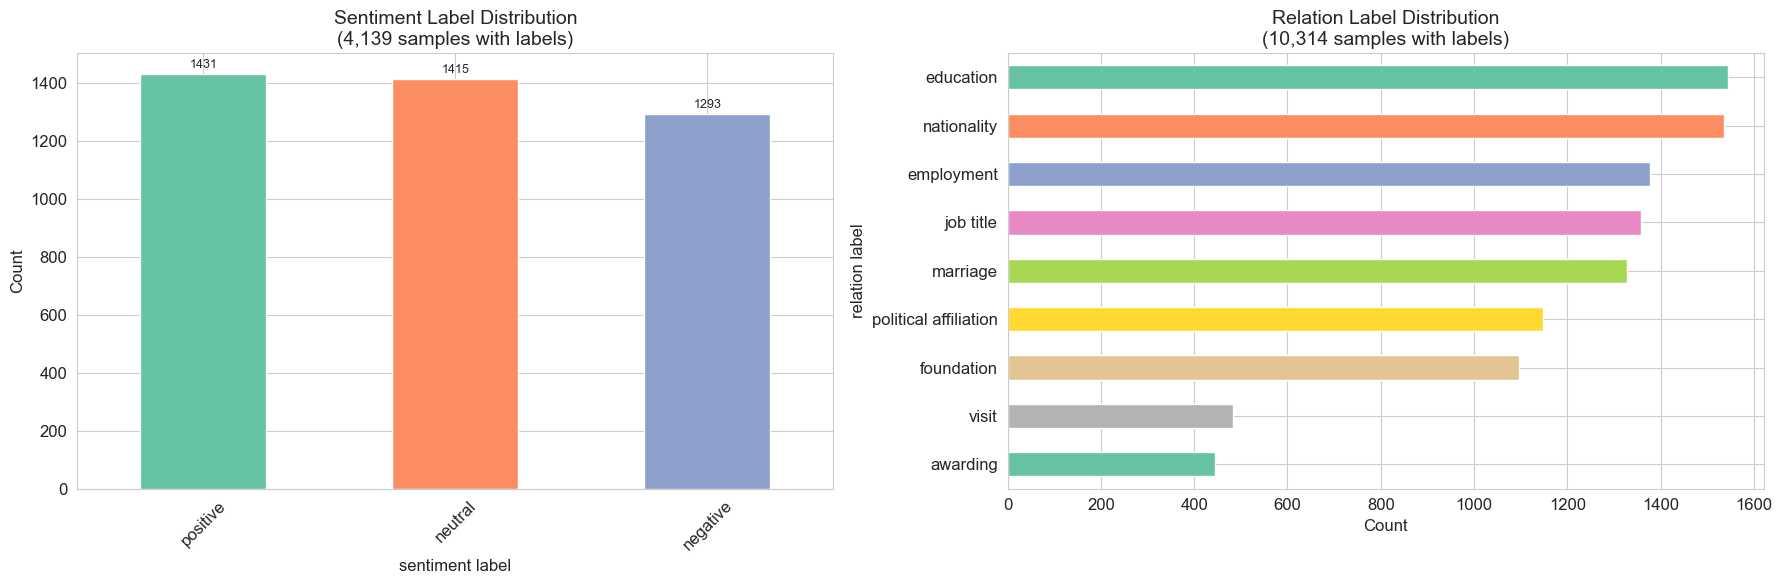

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (a) Sentiment labels (Task 1 only)
sentiment_data = df[df['sentiment label'].notna() & (df['sentiment label'] != '')]
if len(sentiment_data) > 0:
    sent_counts = sentiment_data['sentiment label'].value_counts()
    sent_counts.plot.bar(ax=axes[0], color=palette, rot=45)
    axes[0].set_title(f'Sentiment Label Distribution\n({len(sentiment_data):,} samples with labels)')
    axes[0].set_ylabel('Count')
    for j, (val, cnt) in enumerate(sent_counts.items()):
        axes[0].text(j, cnt + 20, str(cnt), ha='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'No sentiment labels found', transform=axes[0].transAxes, 
                ha='center', fontsize=14)
    axes[0].set_title('Sentiment Labels')

# (b) Relation labels (Task 3 only)
relation_data = df[df['relation label'].notna() & (df['relation label'] != '')]
if len(relation_data) > 0:
    rel_counts = relation_data['relation label'].value_counts()
    rel_counts.plot.barh(ax=axes[1], color=palette)
    axes[1].set_title(f'Relation Label Distribution\n({len(relation_data):,} samples with labels)')
    axes[1].set_xlabel('Count')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No relation labels found', transform=axes[1].transAxes, 
                ha='center', fontsize=14)
    axes[1].set_title('Relation Labels')

plt.tight_layout()
plt.savefig('./eda_figures/09_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSentiment label stats:')
print(f'  Total samples with sentiment: {len(sentiment_data):,}')
print(f'  Unique labels: {sentiment_data["sentiment label"].nunique()}')
print(f'\nRelation label stats:')
print(f'  Total samples with relation: {len(relation_data):,}')
print(f'  Unique labels: {relation_data["relation label"].nunique()}')

---
## 12. Text Variants (Augmentations)

In [12]:
variant_cols = ['input text', 'lexical simplification (v0)', 'lexical simplification (v1)',
                'semantic clarity (v0)', 'semantic clarity (v1)',
                'syntax simplification (v0)', 'syntax simplification (v1)',
                'naive rewritten', 'naive simplified']

# Show an example with all variants
sample_idx = 0
row = df.iloc[sample_idx]

print('📖 Text Variants for Sample 0:')
print('='*80)
for col in variant_cols:
    if col in df.columns:
        text = row[col]
        if isinstance(text, str):
            print(f'\n  [{col}]:')
            print(f'    {text[:120]}' + ('...' if len(text) > 120 else ''))

# Word count comparison across variants
print('\n\n📊 Average word count per variant:')
print('-'*50)
for col in variant_cols:
    if col in df.columns:
        avg_words = df[col].dropna().str.split().str.len().mean()
        print(f'  {col:40s}: {avg_words:.1f} words')

📖 Text Variants for Sample 0:

  [input text]:
    Presents a good case while failing to provide a reason for us to care beyond the very basic dictums of human decency.

  [lexical simplification (v0)]:
    Makes a good point, but doesn't give us a reason to care about the characters.

  [lexical simplification (v1)]:
    The movie makes a good point, but doesn't give us a reason to care about it.

  [semantic clarity (v0)]:
    The movie makes some good points, but it does not give us a compelling reason to emotionally invest in its message beyon...

  [semantic clarity (v1)]:
    The movie presents a good argument but fails to evoke strong emotions beyond basic sympathy.

  [syntax simplification (v0)]:
    The movie makes some good points, but it fails to evoke strong emotions beyond basic human empathy.

  [syntax simplification (v1)]:
    The movie makes some good points, but fails to evoke strong emotions beyond basic human empathy.

  [naive rewritten]:
    It presents a good ca

---
## 13. Cross-Subject EEG Comparison

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\10_cross_subject_eeg.png'

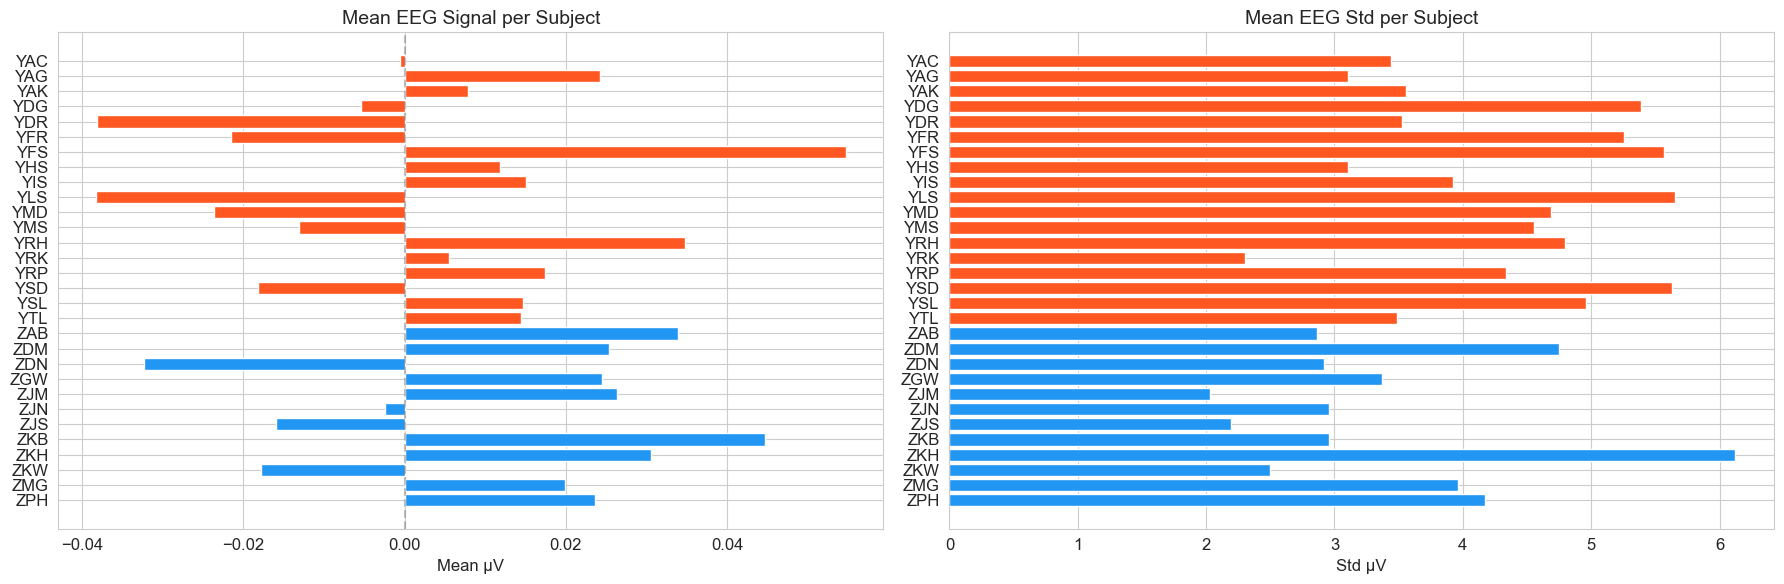

In [13]:
# Compare EEG statistics across subjects
subject_stats = []
for subj in sorted(df['subject'].unique()):
    subj_df = df[df['subject'] == subj]
    # Sample up to 50 recordings per subject
    sample_n = min(50, len(subj_df))
    subset = subj_df.sample(n=sample_n, random_state=42)
    
    means = []
    stds = []
    for _, r in subset.iterrows():
        eeg = r['eeg']
        mask = r['mask']
        eeg_valid = eeg[:mask.sum(), :]
        means.append(eeg_valid.mean())
        stds.append(eeg_valid.std())
    
    subject_stats.append({
        'subject': subj,
        'dataset': 'ZuCo1' if subj.startswith('Z') else 'ZuCo2',
        'mean_of_means': np.mean(means),
        'mean_of_stds': np.mean(stds),
        'n_samples': len(subj_df)
    })

stats_df = pd.DataFrame(subject_stats)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ['#2196F3' if d == 'ZuCo1' else '#FF5722' for d in stats_df['dataset']]

# (a) Mean per subject
axes[0].barh(stats_df['subject'], stats_df['mean_of_means'], color=colors)
axes[0].set_title('Mean EEG Signal per Subject')
axes[0].set_xlabel('Mean μV')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].invert_yaxis()

# (b) Std per subject
axes[1].barh(stats_df['subject'], stats_df['mean_of_stds'], color=colors)
axes[1].set_title('Mean EEG Std per Subject')
axes[1].set_xlabel('Std μV')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('./eda_figures/10_cross_subject_eeg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. EEG Channel Correlation Matrix

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\11_channel_correlation.png'

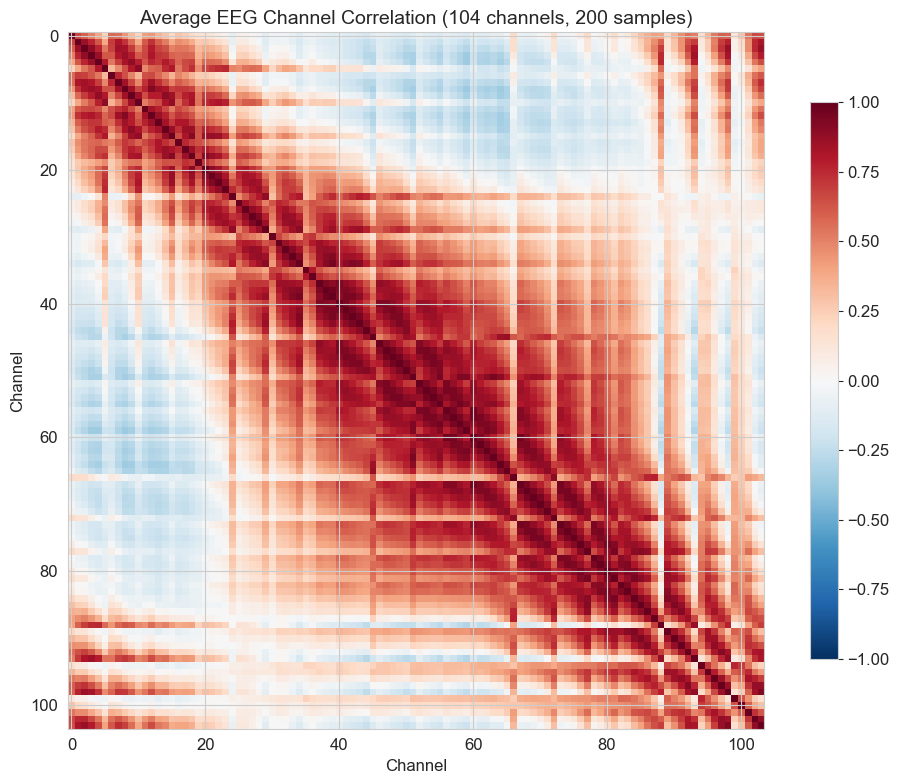

In [14]:
# Compute average channel correlation from a subset
np.random.seed(42)
n_corr = 200
corr_indices = np.random.choice(len(df), size=n_corr, replace=False)

corr_sum = np.zeros((104, 104))  # Only active channels (104 of 128)
for idx in corr_indices:
    row = df.iloc[idx]
    eeg = row['eeg'][:row['mask'].sum(), :104]  # Active channels only
    corr = np.corrcoef(eeg.T)
    corr = np.nan_to_num(corr, nan=0.0)
    corr_sum += corr

avg_corr = corr_sum / n_corr

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(avg_corr, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='none')
ax.set_title(f'Average EEG Channel Correlation (104 channels, {n_corr} samples)')
ax.set_xlabel('Channel')
ax.set_ylabel('Channel')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('./eda_figures/11_channel_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 15. EEG Power Spectral Density (PSD)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\MSc Files\\MSc Project\\E2T-w-VJEPA\\gated-glim\\GLIM\\eda_figures\\12_power_spectral_density.png'

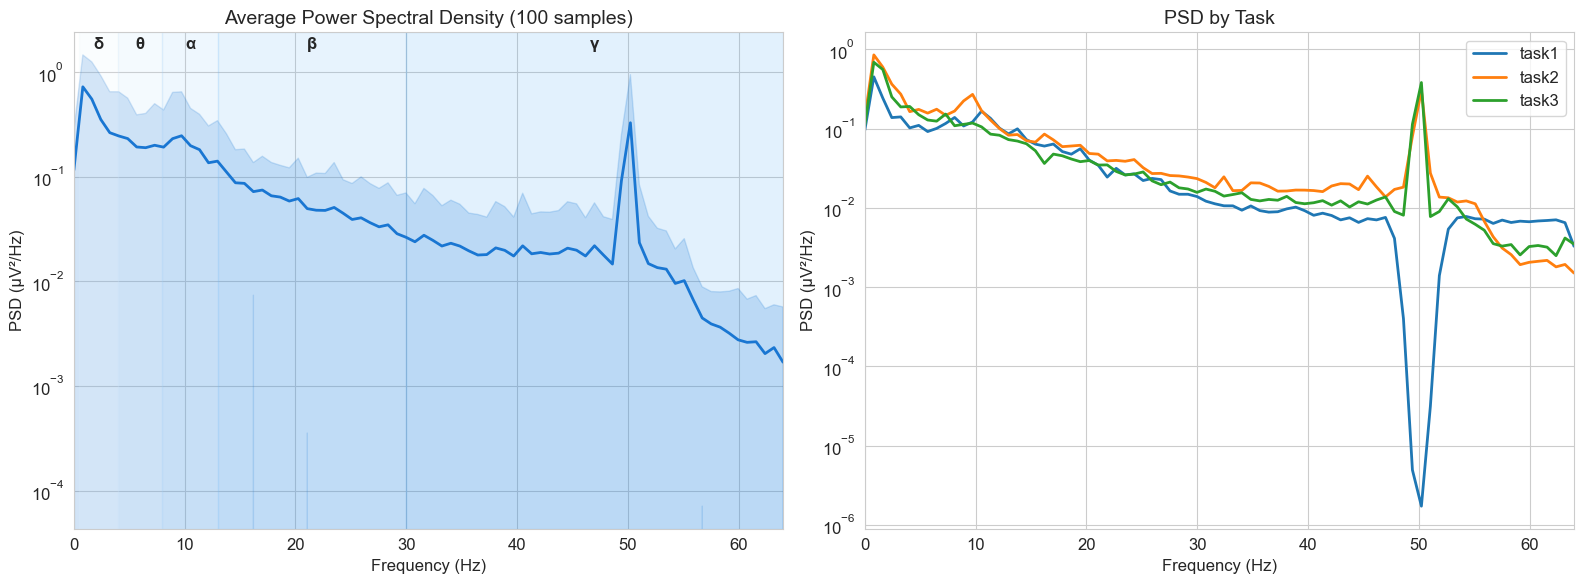

In [15]:
from scipy.signal import welch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average PSD across a subset
np.random.seed(42)
n_psd = 100
psd_indices = np.random.choice(len(df), size=n_psd, replace=False)
fs = 128  # Sampling frequency after downsampling

all_psd = []
for idx in psd_indices:
    row = df.iloc[idx]
    eeg = row['eeg'][:row['mask'].sum(), :]
    # Average across channels, then compute PSD
    avg_signal = eeg.mean(axis=1)
    if len(avg_signal) > 64:  # Need enough points for Welch
        f, psd = welch(avg_signal, fs=fs, nperseg=min(256, len(avg_signal)))
        all_psd.append((f, psd))

# Interpolate to common frequency axis and average
f_common = all_psd[0][0]
psd_matrix = np.array([np.interp(f_common, f, p) for f, p in all_psd])
avg_psd = psd_matrix.mean(axis=0)
std_psd = psd_matrix.std(axis=0)

# (a) Average PSD
axes[0].semilogy(f_common, avg_psd, color='#1976D2', linewidth=2)
axes[0].fill_between(f_common, avg_psd - std_psd, avg_psd + std_psd, alpha=0.2, color='#1976D2')
axes[0].set_title(f'Average Power Spectral Density ({n_psd} samples)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('PSD (μV²/Hz)')
axes[0].set_xlim(0, 64)

# Add EEG band annotations
bands = {'δ': (0.5, 4), 'θ': (4, 8), 'α': (8, 13), 'β': (13, 30), 'γ': (30, 64)}
colors_band = ['#E3F2FD', '#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5']
for (name, (lo, hi)), c in zip(bands.items(), colors_band):
    axes[0].axvspan(lo, hi, alpha=0.15, color=c)
    axes[0].text((lo + hi) / 2, axes[0].get_ylim()[1] * 0.7, name, ha='center', fontsize=12, fontweight='bold')

# (b) PSD by task
for task in sorted(df['task'].unique()):
    task_indices = df[df['task'] == task].sample(n=min(50, sum(df['task'] == task)), random_state=42).index
    task_psds = []
    for idx in task_indices:
        pos = df.index.get_loc(idx)
        row = df.iloc[pos]
        eeg = row['eeg'][:row['mask'].sum(), :]
        avg_signal = eeg.mean(axis=1)
        if len(avg_signal) > 64:
            f, psd = welch(avg_signal, fs=fs, nperseg=min(256, len(avg_signal)))
            task_psds.append(np.interp(f_common, f, psd))
    if task_psds:
        task_avg = np.mean(task_psds, axis=0)
        axes[1].semilogy(f_common, task_avg, linewidth=2, label=task)

axes[1].set_title('PSD by Task')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD (μV²/Hz)')
axes[1].set_xlim(0, 64)
axes[1].legend()

plt.tight_layout()
plt.savefig('./eda_figures/12_power_spectral_density.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 16. Summary Statistics Table

In [16]:
# Final summary
print('='*70)
print('DATASET SUMMARY')
print('='*70)

summary = {
    'Total Samples': len(df),
    'Unique Sentences': df['text uid'].nunique(),
    'Total Subjects': df['subject'].nunique(),
    'ZuCo1 Subjects': sum(1 for s in df['subject'].unique() if s.startswith('Z')),
    'ZuCo2 Subjects': sum(1 for s in df['subject'].unique() if s.startswith('Y')),
    'Train Samples': len(df[df['phase'] == 'train']),
    'Val Samples': len(df[df['phase'] == 'val']),
    'Test Samples': len(df[df['phase'] == 'test']),
    'EEG Shape': '(1280, 128)',
    'Sampling Rate': '128 Hz (downsampled from 500 Hz)',
    'Active Channels': '104 (of 128, last 24 zero-padded)',
    'Tasks': 'task1 (SR), task2 (NR), task3 (TSR)',
    'Sentiment Labels': df['sentiment label'].dropna().nunique(),
    'Relation Labels': df['relation label'].dropna().nunique(),
    'Text Variants': 8,
}

for k, v in summary.items():
    print(f'  {k:30s}: {v}')

print('\n' + '='*70)
print('TASK BREAKDOWN')
print('='*70)
task_summary = df.groupby(['task', 'phase']).size().unstack(fill_value=0)
task_summary['total'] = task_summary.sum(axis=1)
print(task_summary.to_string())

# Clean up temp columns
df.drop(columns=['actual_len', 'duration_s', 'text_len_chars', 'text_len_words'], 
        inplace=True, errors='ignore')

DATASET SUMMARY
  Total Samples                 : 22335
  Unique Sentences              : 1529
  Total Subjects                : 30
  ZuCo1 Subjects                : 12
  ZuCo2 Subjects                : 18
  Train Samples                 : 17908
  Val Samples                   : 2200
  Test Samples                  : 2227
  EEG Shape                     : (1280, 128)
  Sampling Rate                 : 128 Hz (downsampled from 500 Hz)
  Active Channels               : 104 (of 128, last 24 zero-padded)
  Tasks                         : task1 (SR), task2 (NR), task3 (TSR)
  Sentiment Labels              : 3
  Relation Labels               : 9
  Text Variants                 : 8

TASK BREAKDOWN
phase  test  train  val  total
task                          
task1   417   3316  406   4139
task2   827   6231  824   7882
task3   983   8361  970  10314


---
## 17. Before vs After Preprocessing Comparison

In [17]:
if HAS_RAW:
    print('Comparing raw (intermediate) vs final preprocessed data:')
    print(f'  Raw samples:  {len(df_raw):,} (columns: {list(df_raw.columns)})')
    print(f'  Final samples: {len(df):,} (columns: {len(df.columns)} total)')
    print(f'  Same count: {len(df_raw) == len(df)}')
    print()
    print('  Columns added during preprocessing:')
    for col in df.columns:
        if col not in df_raw.columns:
            print(f'    + {col}')
    print()
    print('  Columns removed/renamed during preprocessing:')
    for col in df_raw.columns:
        if col not in df.columns:
            print(f'    - {col}')
    
    # Compare EEG shapes
    raw_eeg = df_raw.iloc[0]['eeg']
    proc_eeg = df.iloc[0]['eeg']
    print(f'\n  Raw EEG shape:  {raw_eeg.shape}')
    print(f'  Final EEG shape: {proc_eeg.shape}')
    print(f'  Shapes match: {raw_eeg.shape == proc_eeg.shape}')
else:
    print('⚠️ Intermediate data file not available for comparison.')
    print('The intermediate file (zuco_eeg_128ch_1280len.df) contains the EEG data')
    print('AFTER downsampling and padding, but BEFORE label matching and splitting.')
    print()
    print('Key preprocessing steps:')
    print('  1. Raw .mat files: 500Hz, 105 channels → loaded from ZuCo1/ZuCo2')
    print('  2. Remove last channel (all zeros) → 104 channels')
    print('  3. Filter by length: keep 0.5s–10s recordings at 500Hz')
    print('  4. Downsample: 500Hz → 128Hz via scipy.signal.resample')
    print('  5. Zero-pad: to 1280 time points, 128 channels')
    print('  6. Create mask: 1 for real signal, 0 for padding')
    print('  7. Match with text labels & split into train/val/test')

Comparing raw (intermediate) vs final preprocessed data:
  Raw samples:  22,335 (columns: ['eeg', 'mask', 'text', 'dataset', 'task', 'subject'])
  Final samples: 22,335 (columns: 22 total)
  Same count: True

  Columns added during preprocessing:
    + label id
    + raw text
    + control
    + raw label
    + input text
    + text uid
    + sentiment label
    + relation label
    + lexical simplification (v0)
    + lexical simplification (v1)
    + semantic clarity (v0)
    + semantic clarity (v1)
    + syntax simplification (v0)
    + syntax simplification (v1)
    + naive rewritten
    + naive simplified
    + phase

  Columns removed/renamed during preprocessing:
    - text

  Raw EEG shape:  (1280, 128)
  Final EEG shape: (1280, 128)
  Shapes match: True


In [18]:
print('\n✅ EDA Complete!')
print(f'📁 Figures saved to ./eda_figures/')


✅ EDA Complete!
📁 Figures saved to ./eda_figures/
